# Test TabICL

In [14]:
import time

import shap
import torch
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from tabicl import TabICLClassifier
import matplotlib.pyplot as plt
import matplotlib

## 1. Données et modèles

In [2]:
X, y = load_breast_cancer(return_X_y=True, as_frame=True)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=0, stratify=y
)

print(X_train.shape, X_test.shape)

(426, 30) (143, 30)


In [5]:
modeles ={
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=0),
    "TabICL": TabICLClassifier(),
    "TabICL + kv_cache": TabICLClassifier(kv_cache=True)
}

for nom, modele in modeles.items():
    debut = time.perf_counter()
    modele.fit(X_train, y_train)
    duree_fit = time.perf_counter() - debut

    debut = time.perf_counter()
    score = modele.score(X_test, y_test)
    duree_predict = time.perf_counter() - debut

    print(f"{nom:<20} fit : {duree_fit:6.2f} s   predict ({len(X_test)} lignes) : {duree_predict:6.2f} s   accuracy : {score:.3f}")

Gradient Boosting    fit :   0.35 s   predict (143 lignes) :   0.00 s   accuracy : 0.937
INFO: You are downloading 'tabicl-classifier-v2-20260212.ckpt', the latest best-performing version, used in our TabICLv2 paper.

Checkpoint 'tabicl-classifier-v2-20260212.ckpt' not cached.

TabICL               fit :   3.62 s   predict (143 lignes) :  14.25 s   accuracy : 0.965
TabICL + kv_cache    fit :   8.60 s   predict (143 lignes) :   3.41 s   accuracy : 0.965


## 2. Un compteur de prédictions

On enveloppe la fonction de prédiction dans une petite classe qui compte le nombre de **lignes** prédites et le nombre d'**appels**.

In [6]:
class CompteurPredictions:
    """Enveloppe predict_proba d'un modèle et compte les lignes prédites."""

    def __init__(self, modele):
        self.modele = modele
        self.nb_lignes = 0
        self.nb_appels = 0

    def __call__(self, X):
        self.nb_lignes += len(X)
        self.nb_appels += 1
        return self.modele.predict_proba(X)[:, 1]

## 3. SHAP : combien de prédictions, combien de temps ?

Paramètres du test : on explique `NB_LIGNES` prédictions, avec un échantillon de référence de `MAX_SAMPLES` lignes. Commencez petit : sur CPU, TabICL peut être long.

In [8]:
NB_LIGNES = 3
MAX_SAMPLES = 50

resultats_shap = {}

for nom, modele in modeles.items():
    compteur = CompteurPredictions(modele)
    explainer = shap.Explainer(
        compteur,
        shap.maskers.Independent(X_train, max_samples=MAX_SAMPLES),
    )

    debut = time.perf_counter()
    valeurs_shap = explainer(X_test.iloc[:NB_LIGNES])
    duree = time.perf_counter() - debut

    resultats_shap[nom] = valeurs_shap
    print(
        f"{nom:<20} {compteur.nb_lignes:>8} lignes prédites "
        f"en {compteur.nb_appels:>4} appels   durée : {duree:7.1f} s"
    )

Background dataset has 426 samples but max_samples=50. Subsampling to 50 samples for SHAP value computation. To use all samples, set max_samples=426 when initializing the masker.
Background dataset has 426 samples but max_samples=50. Subsampling to 50 samples for SHAP value computation. To use all samples, set max_samples=426 when initializing the masker.


Gradient Boosting       76236 lignes prédites en   26 appels   durée :     8.2 s


PermutationExplainer explainer: 4it [09:06, 182.27s/it]                      
Background dataset has 426 samples but max_samples=50. Subsampling to 50 samples for SHAP value computation. To use all samples, set max_samples=426 when initializing the masker.


TabICL                  76236 lignes prédites en   26 appels   durée :   546.8 s


PermutationExplainer explainer: 4it [08:18, 166.20s/it]                      

TabICL + kv_cache       76236 lignes prédites en   26 appels   durée :   498.6 s


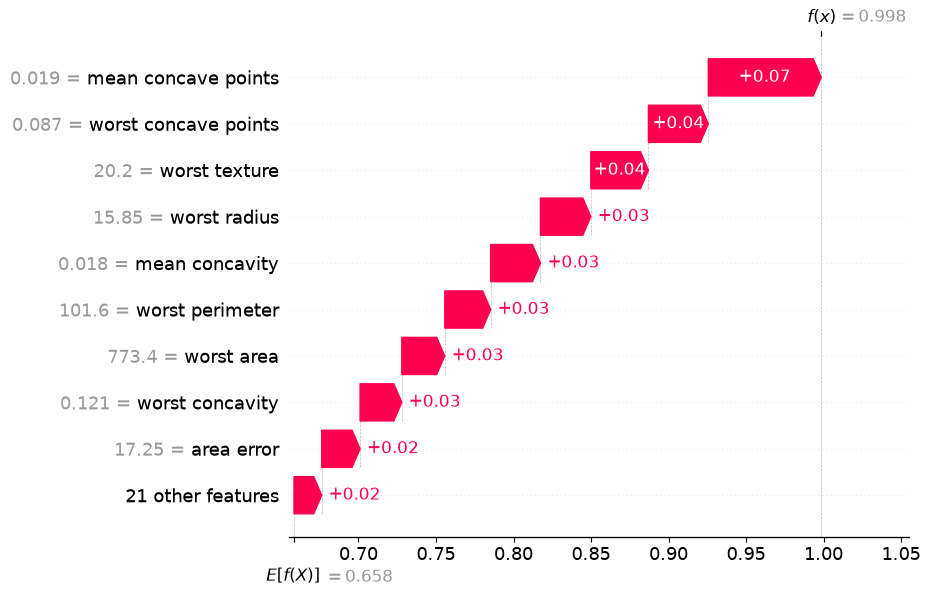

In [22]:
# Visualiser l'explication de la première prédiction de TabICL
shap.plots.waterfall(resultats_shap["TabICL"][0])

## 4. Faire varier les paramètres

Comment évolue le coût quand on change la taille de l'échantillon de référence ? (Sur le modèle à arbres seulement, pour que ce soit rapide : le nombre de prédictions ne dépend pas du modèle.)

In [24]:
for max_samples in [10, 50, 100]:
    compteur = CompteurPredictions(modeles["Gradient Boosting"])
    explainer = shap.Explainer(compteur, shap.maskers.Independent(X_train, max_samples=max_samples))
    explainer(X_test.iloc[:NB_LIGNES])
    print(f"max_samples = {max_samples:>3} → {compteur.nb_lignes:>8} lignes prédites pour {NB_LIGNES} lignes expliquées")

Background dataset has 426 samples but max_samples=10. Subsampling to 10 samples for SHAP value computation. To use all samples, set max_samples=426 when initializing the masker.
Background dataset has 426 samples but max_samples=50. Subsampling to 50 samples for SHAP value computation. To use all samples, set max_samples=426 when initializing the masker.
Background dataset has 426 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=426 when initializing the masker.


max_samples =  10 →    15244 lignes prédites pour 3 lignes expliquées
max_samples =  50 →    76236 lignes prédites pour 3 lignes expliquées
max_samples = 100 →   152536 lignes prédites pour 3 lignes expliquées


## 5. Pour comparer : l'importance par permutation

Beaucoup moins coûteuse : `n_repeats` × nombre de variables appels à `predict`, chacun sur tout le jeu de test.

In [ ]:
for nom, modele in modeles.items():
    debut = time.perf_counter()
    resultat = permutation_importance(modele, X_test, y_test, n_repeats=5, random_state=0)
    duree = time.perf_counter() - debut
    print(f"{nom:<20} durée : {duree:7.1f} s")

Gradient Boosting    durée :     0.6 s
